In [194]:
%matplotlib inline

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree

In [74]:
ruspini = pd.read_csv("./data/ruspini.csv")
food = pd.read_csv("./data/food.csv", sep = ';')

In [77]:
ruspini = ruspini.drop('Unnamed: 0', axis = 1)
ruspini.head()

,x,y
0,4,53
1,5,63
2,10,59
3,9,77
4,13,49


In [78]:
food.head()

,Name,Energy,Protein,Fat,Calcium,Iron
0,Braised beef,340,20,28,9,2.6
1,Hamburger,245,21,17,9,2.7
2,Roast beef,420,15,39,7,2.0
3,Beefsteak,375,19,32,9,2.6
4,Canned beef,180,22,10,17,3.7


<Axes: ylabel='y'>

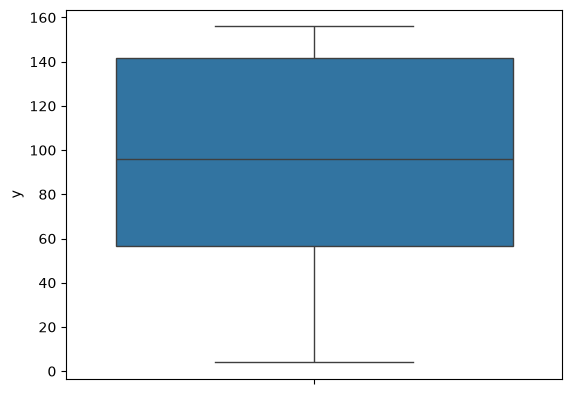

In [79]:
#sns.boxplot(ruspini["x"])
sns.boxplot(ruspini["y"])

<Axes: ylabel='Iron'>

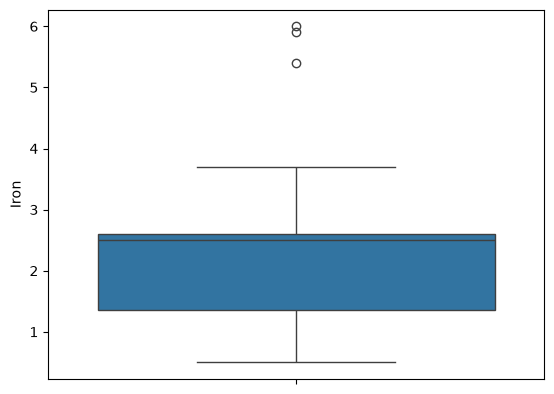

In [80]:
sns.boxplot(food["Iron"])

<Axes: xlabel='x', ylabel='y'>

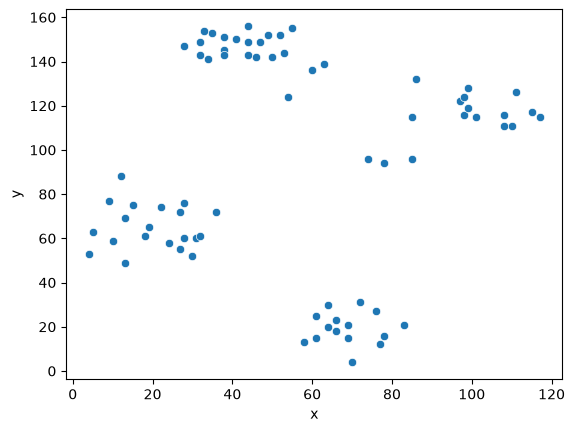

In [53]:
# 4 clusters in ruspini dataset looks like
sns.scatterplot(ruspini, x = "x", y = "y")

### 1. K-Means Implementation and Silhoutte Score vs Clusters

In [106]:
kmeans_4 = KMeans(n_clusters = 4)
kmeans_4.fit(ruspini)
kmeans_4.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

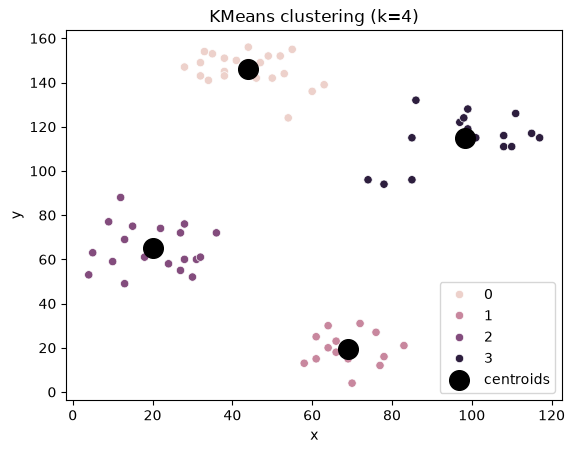

In [107]:
sns.scatterplot(ruspini, x = "x", y = "y", hue = kmeans_4.labels_)
plt.scatter(
    kmeans_4.cluster_centers_[:, 0], kmeans_4.cluster_centers_[:, 1],
    c="black", marker="o", s=200, label="centroids"
)
plt.legend()
plt.title("KMeans clustering (k=4)")
plt.show()

In [129]:
silhouette_scores = []
inertias = []

for i in range(2, 10):
    kmeans_i = KMeans(n_clusters = i).fit(ruspini)
    silhouette_scores.append([silhouette_score(ruspini, kmeans_i.labels_), i])
    inertias.append([kmeans_i.inertia_, i])

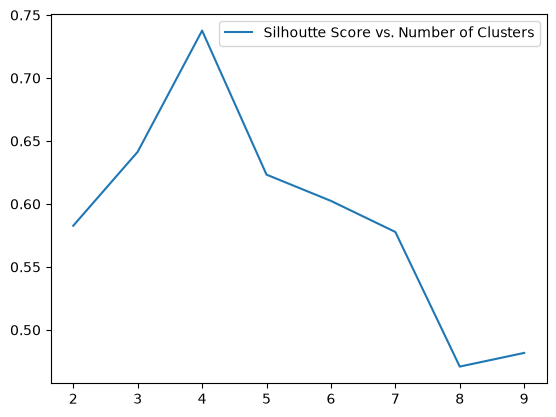

In [130]:
score = [item[0] for item in silhouette_scores]
clusters = [item[1] for item in silhouette_scores]

sns.lineplot(x = clusters, y = score, label = "Silhoutte Score vs. Number of Clusters")


plt.show()

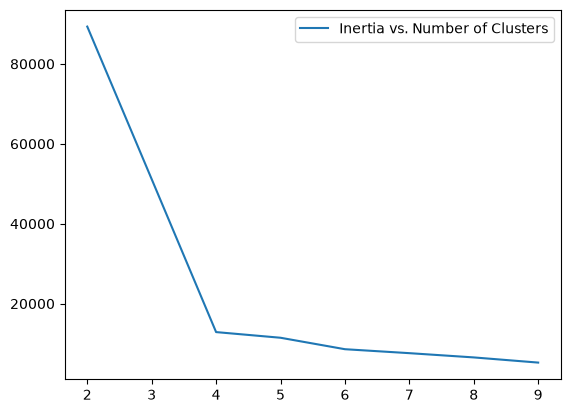

In [131]:
inertia = [item[0] for item in inertias]
clusters = [item[1] for item in inertias]

sns.lineplot(x = clusters, y = inertia, label = "Inertia vs. Number of Clusters")

plt.show()

### 2. Hierarchical Clustering

In [142]:
food.head()

,Name,Energy,Protein,Fat,Calcium,Iron
0,Braised beef,340,20,28,9,2.6
1,Hamburger,245,21,17,9,2.7
2,Roast beef,420,15,39,7,2.0
3,Beefsteak,375,19,32,9,2.6
4,Canned beef,180,22,10,17,3.7


<Axes: >

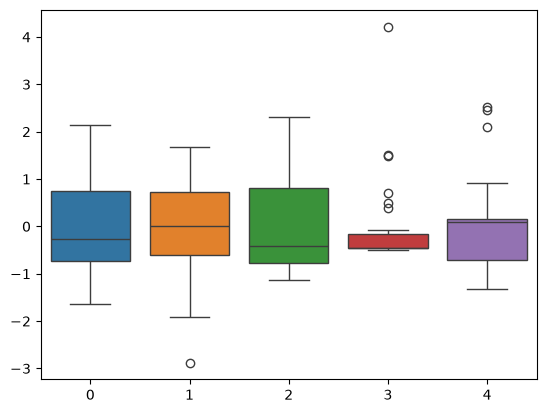

In [143]:
food_numeros = food[["Energy", "Protein", "Fat", "Calcium", "Iron"]]
food_standard_scaled = StandardScaler().fit_transform(food_numeros)
sns.boxplot(food_standard_scaled)

<Axes: >

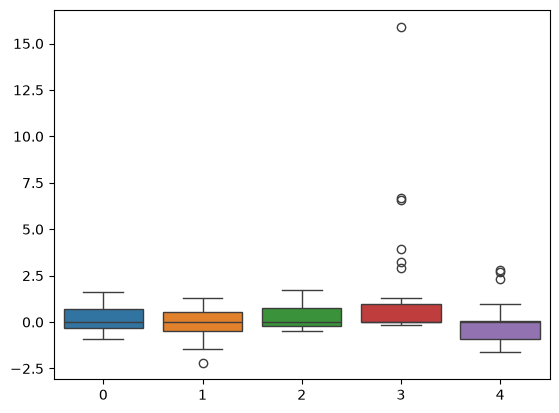

In [144]:
food_numeros = food[["Energy", "Protein", "Fat", "Calcium", "Iron"]]
food_robust_scaled = RobustScaler().fit_transform(food_numeros)
sns.boxplot(food_robust_scaled)

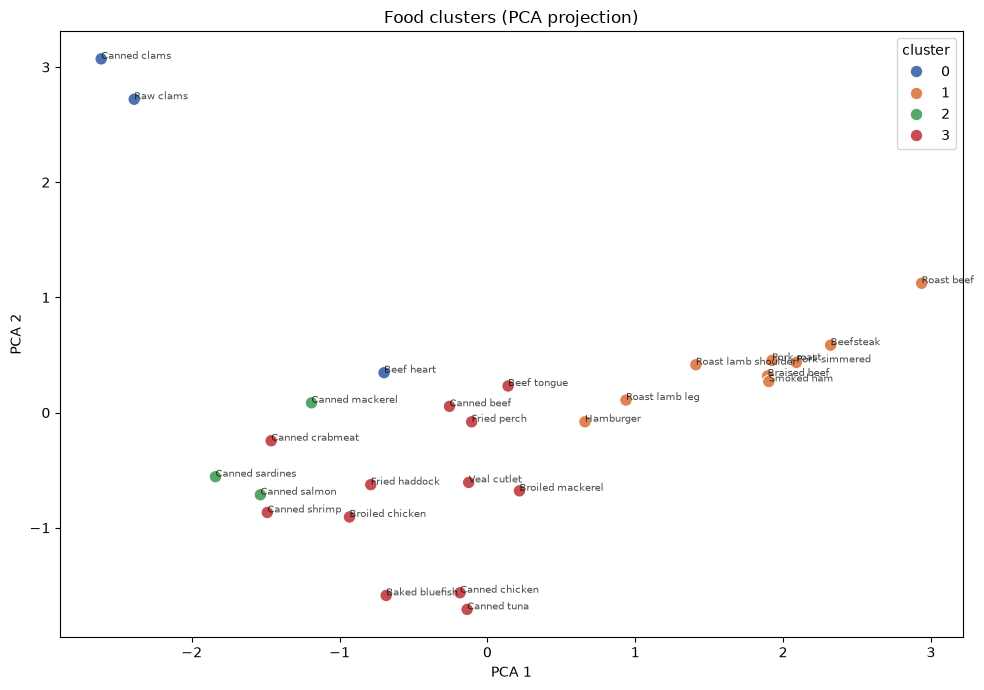

In [197]:
# Trying KMeans for this and then using PCA to reduce dimension to visualize the results
kmeans_4 = KMeans(n_clusters = 4)
kmeans_4.fit(food_standard_scaled)
labels = kmeans_4.labels_

# project 5D -> 2D just for plotting
coords = PCA(n_components=2).fit_transform(food_standard_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=labels, palette="deep", s=80)

# Mapping initial names to the reduced dimension
for i, name in enumerate(food["Name"]):
    plt.annotate(name, (coords[i, 0], coords[i, 1]), fontsize=7, alpha=0.7)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Food clusters (PCA projection)")
plt.legend(title="cluster")
plt.tight_layout()
plt.show()

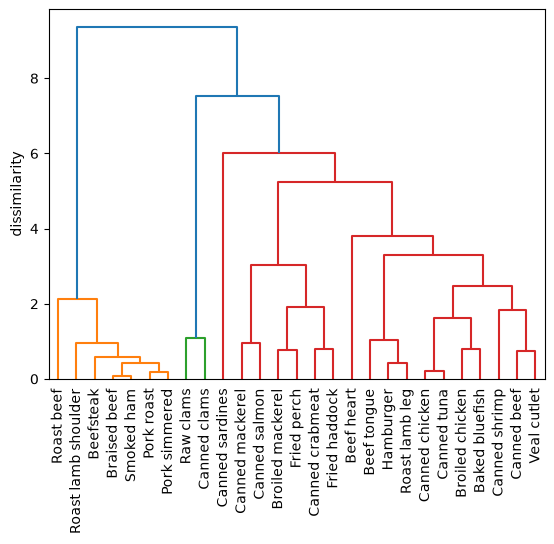

In [198]:
#food_diss = linkage(food_robust_scaled, method="ward", metric="euclidean")
#food_diss = linkage(food_standard_scaled, method="average", metric="euclidean")
#food_diss = linkage(food_standard_scaled, method="average", metric="cityblock")
food_diss = linkage(food_standard_scaled, method="ward", metric='euclidean')
dendrogram(food_diss, labels=food["Name"].values, leaf_rotation=90)
plt.ylabel("dissimilarity")
plt.show()

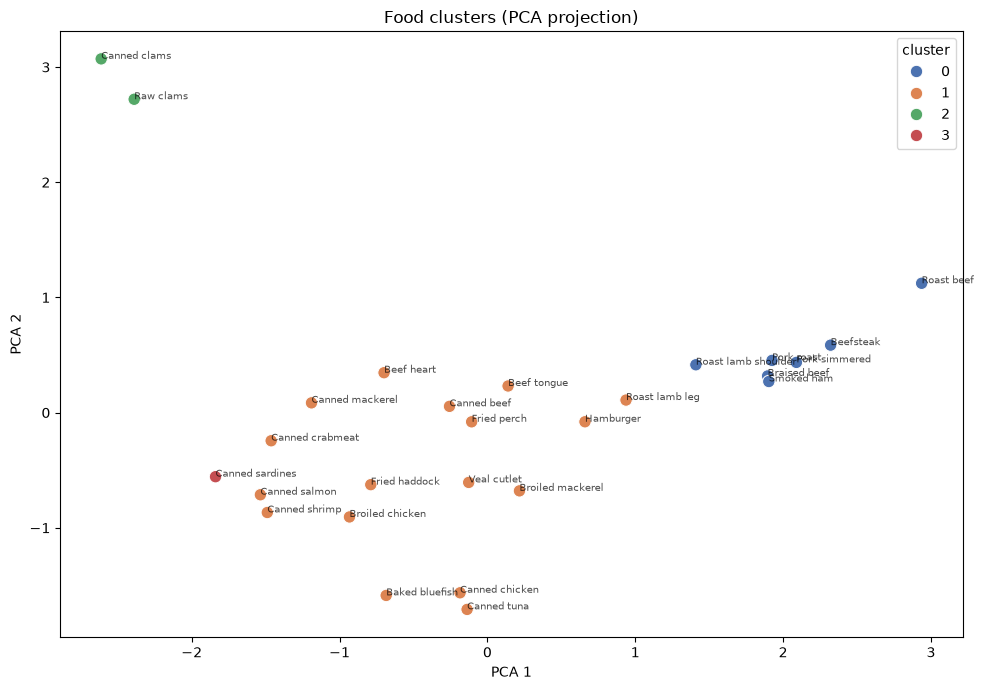

In [218]:
level_4 = cut_tree(food_diss, n_clusters = 4)

# Plotting the same PCA plot but now with labels from aggro
coords = PCA(n_components=2).fit_transform(food_standard_scaled)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=[item[0] for item in level_4], palette="deep", s=80)

# Mapping initial names to the reduced dimension
for i, name in enumerate(food["Name"]):
    plt.annotate(name, (coords[i, 0], coords[i, 1]), fontsize=7, alpha=0.7)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Food clusters (PCA projection)")
plt.legend(title="cluster")
plt.tight_layout()
plt.show()